In [1]:
# (데이터 증강 + CNN 개선)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 학습 데이터 불러오기
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/OSS/dataset/raw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=16
)

Found 502 files belonging to 4 classes.
Using 402 files for training.
Found 502 files belonging to 4 classes.
Using 100 files for validation.


In [3]:
# 클래스 이름
class_names = train_ds.class_names

print("클래스 목록")
print(class_names)

클래스 목록
['can', 'paper', 'plastic', 'vinyl']


In [4]:
# 데이터 증강
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [11]:
# 모델 생성
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [12]:
# 컴파일

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# EarlyStopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [14]:
# 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.3259 - loss: 1.7314 - val_accuracy: 0.3800 - val_loss: 1.3272
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.3881 - loss: 1.2755 - val_accuracy: 0.4100 - val_loss: 1.3511
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.4129 - loss: 1.2503 - val_accuracy: 0.3900 - val_loss: 1.3230
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.4403 - loss: 1.1339 - val_accuracy: 0.3900 - val_loss: 1.4202
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.4602 - loss: 1.1187 - val_accuracy: 0.4200 - val_loss: 1.1435
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.5572 - loss: 0.9652 - val_accuracy: 0.4400 - val_loss: 1.7321
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.5149 - loss: 1.0010 - val_accuracy: 0.3200 - val_loss: 2.8889
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.4279 - loss: 1.2680 - val_accuracy: 0.3400 - val_

In [15]:
# 평가
loss, acc = model.evaluate(val_ds)

print(f"Validation Accuracy : {acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4200 - loss: 1.1435
Validation Accuracy : 0.4200


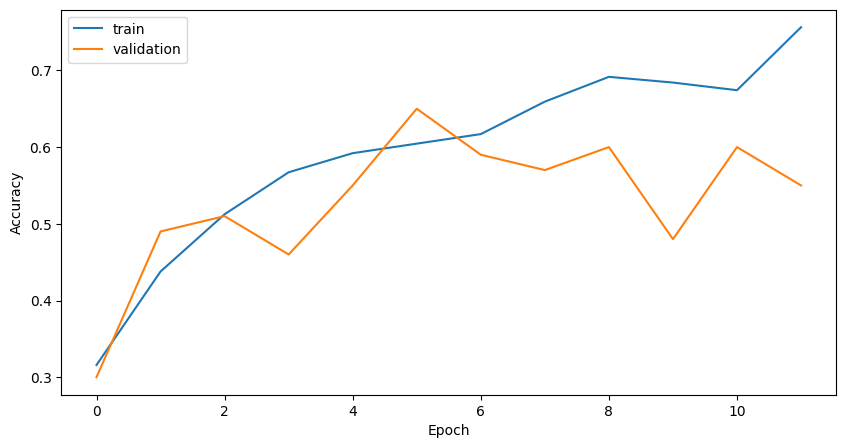

In [ ]:
import matplotlib.pyplot as plt

# 그래프
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [10]:
print(history.history['val_loss'])
print(history.history['val_accuracy'])

[1.3817235231399536, 1.3182944059371948, 1.2683275938034058, 1.2531102895736694, 1.2833033800125122, 1.1773693561553955, 1.0378849506378174, 1.1444578170776367, 1.1520110368728638, 1.2277861833572388, 1.1218748092651367, 1.0929759740829468]
[0.25999999046325684, 0.33000001311302185, 0.3499999940395355, 0.3400000035762787, 0.5, 0.5299999713897705, 0.550000011920929, 0.5099999904632568, 0.5400000214576721, 0.4699999988079071, 0.5799999833106995, 0.6299999952316284]
